# 🚌 EDA Bizkaibus — Análisis de Viajeros 2020-2025

**Fuente:** [Open Data Bizkaia](https://www.opendatabizkaia.eus/es/catalogo/bizkaibus)  
**Período:** Enero 2020 – Diciembre 2025  
**Archivos:** 18 CSVs (2 semestrales por año en 2020-2022, 4 trimestrales por año en 2023-2025)  
**Granularidad:** una fila = una línea en un mes concreto


## 🎯 Hipótesis de Partida

| # | Hipótesis |
|---|-----------|
| H1 | Los títulos bonificados para jóvenes representan una proporción significativa del total de viajeros. |
| H2 | Hay meses con más afluencia que otros. |
| H3 | Las líneas que más crecen son las que conectan con Bilbao. |
| H4 | Las ayudas al transporte han impulsado el uso del autobús. |

> **Contexto H4:** En septiembre de 2022, el Gobierno Vasco completó una bonificación del 40% adicional a la del Ministerio de Transportes (30%), resultando en una **bonificación total del 50%** en todo el transporte público de Euskadi. Esta medida sigue vigente en la actualidad.


## 0. Imports y Configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)

# ── AJUSTA ESTA RUTA AL DIRECTORIO DONDE TIENES LOS CSV ──────
DATA_DIR = Path('bizkaibus')
# ─────────────────────────────────────────────────────────────


## 1. Carga y Unión de Datasets

Cargamos los 18 archivos CSV con `glob` y los concatenamos en un único DataFrame.  
Añadimos `archivo_origen` para trazabilidad durante la limpieza.


In [3]:
archivos = sorted(DATA_DIR.glob('*_biz_*.csv'))
print(f"Archivos encontrados: {len(archivos)}")
for a in archivos:
    print(f"  · {a.name}")


Archivos encontrados: 18
  · 2020_biz_dic.csv
  · 2020_biz_jun.csv
  · 2021_biz_dic.csv
  · 2021_biz_jun.csv
  · 2022_biz_dic.csv
  · 2022_biz_jun.csv
  · 2023_biz_dic.csv
  · 2023_biz_jun.csv
  · 2023_biz_mar.csv
  · 2023_biz_sept.csv
  · 2024_biz_dic.csv
  · 2024_biz_jun.csv
  · 2024_biz_mar.csv
  · 2024_biz_sept.csv
  · 2025_biz_dic.csv
  · 2025_biz_jun.csv
  · 2025_biz_mar.csv
  · 2025_biz_sept.csv


In [4]:
dfs = []
for ruta in archivos:
    df_temp = pd.read_csv(ruta, encoding='utf-8-sig')
    df_temp['archivo_origen'] = ruta.name
    dfs.append(df_temp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Shape total: {df_raw.shape}")
df_raw.head(3)


Shape total: (6852, 45)


,_id,EKITALDIA/EJERCICIO,HILABETE/MES,ZENBAKIA/CODIGO,LERROA/LINEA,CREDITRANS/CREDITRANS,CREDITRANS F20/CREDITRANS F20,CREDITRANS F50/CREDITRANS F50,GIZATRANS/GIZATRANS,GIZATRANS 20/GIZATRANS 20,GIZATRANS 50/GIZATRANS 50,BBCARD 24/BBCARD 24,BBCARD 48/BBCARD 48,BBCARD 72/BBCARD 72,GAZTE 70/GAZTE 70,GAZTE 70 F20/GAZTE 70 F20,GAZTE 70 F50/GAZTE 70 F50,GORO/GORO,GORO F20/GORO F20,GORO F50/GORO F50,OHIKOA/OCASIONAL,FAMILIA UGARIA/FAMILIA NUMEROSA,6 URTETIK BEHERAKOAK/MENORES DE 6 ANOS,ITSU-MUP-EN GIDARI-LAGUN/ACOMPANANTE INVIDENTE-PMRS,METROA/METRO,T.M MATXURA/PUP AVERIADO,ENPRESA/EMPRESA,GUZTIRA/TOTAL,archivo_origen,B 50/B 50,B50 F20/B50 F20,B50 F50/B50 F50,B70/B70,B70 F20/B70 F20,B70 F50/B70 F50,BORO/BORO,BORO F20/BORO F20,BORO F50/BORO F50,BAT/BAT,BAT F20/BAT F20,BAT F50/BAT F50,BAT BEREZI/BAT BEREZI,BAT BEREZI F20/BAT BEREZI F20,BAT BEREZI F50/BAT BEREZI F50,ITSU-MUPEN DOAKO GIDARILAGUN/ACOMPANANTE GRATIS INVIDENTE-PMRS
0,1,2020,7,A2610,GALDAKAO - UPV/EHU,864,4,1,51,0,0,0,0,0,30,0,0,5,0,0,0,0,2,0,0,0,0,957,2020_biz_dic.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2020,7,A2611,UGAO MIRABALLES - BASAURI - ETXEBARRI - UPV/EHU,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2020_biz_dic.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2020,7,A3613,BILBAO - UGAO MIRABALLES - OROZKO,"14,240",274,73,"6,329",10,0,0,0,0,217,28,0,278,2,4,0,0,183,9,0,0,146,"21,793",2020_biz_dic.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploración Inicial

In [5]:
print("─── Tipos de datos ─────────────────────────────")
print(df_raw.dtypes.value_counts())
print()
print("─── Años disponibles ───────────────────────────")
print(sorted(df_raw['EKITALDIA/EJERCICIO'].unique()))
print()
print("─── Meses disponibles ──────────────────────────")
print(sorted(df_raw['HILABETE/MES'].unique()))
print()
print(f"─── Líneas únicas ──────────────────────────────")
print(df_raw['LERROA/LINEA'].nunique())
print()
print("─── Primeras columnas ──────────────────────────")
print(list(df_raw.columns[:10]))
print(f"  ... y {len(df_raw.columns) - 10} columnas más")


─── Tipos de datos ─────────────────────────────
float64    39
int64       3
str         3
Name: count, dtype: int64

─── Años disponibles ───────────────────────────
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

─── Meses disponibles ──────────────────────────
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

─── Líneas únicas ──────────────────────────────
104

─── Primeras columnas ──────────────────────────
['_id', 'EKITALDIA/EJERCICIO', 'HILABETE/MES', 'ZENBAKIA/CODIGO', 'LERROA/LINEA', 'CREDITRANS/CREDITRANS', 'CREDITRANS F20/CREDITRANS F20', 'CREDITRANS F50/CREDITRANS F50', 'GIZATRANS/GIZATRANS', 'GIZATRANS 20/GIZATRANS 20']
  ... y 35 columnas más


In [6]:
# Resumen estadístico (top columnas por media)
df_raw.describe().T.sort_values('mean', ascending=False).head(15)


,count,mean,std,min,25%,50%,75%,max
GUZTIRA/TOTAL,"6,852","22,715","32,353",0,"3,667","13,614","33,574","1,165,317"
CREDITRANS/CREDITRANS,"6,658","14,767","19,315",0,"2,725","9,414","22,543","569,362"
GIZATRANS/GIZATRANS,"6,574","3,514","4,598",0,309,"1,775","5,107","88,648"
EKITALDIA/EJERCICIO,"6,852","2,022",2,"2,020","2,021","2,022","2,024","2,025"
OHIKOA/OCASIONAL,"6,703","1,209","7,682",0,52,356,"1,176","531,070"
BORO/BORO,"2,250","1,180","1,847",0,75,554,"1,502","23,498"
GAZTE 70/GAZTE 70,"6,282",981,"1,321","-2,908",121,575,"1,369","38,552"
GORO/GORO,"6,271",891,"1,427","-2,164",129,472,"1,158","40,229"
B 50/B 50,"2,250",803,"1,153",0,59,462,"1,160","22,462"
CREDITRANS F20/CREDITRANS F20,"6,405",492,651,0,101,335,686,"21,781"


## 3. Limpieza

### 3.1 Renombrado de Columnas

Los nombres originales tienen el formato `EUSKERA/CASTELLANO`.  
Extraemos la parte en castellano y convertimos a `snake_case`.


In [7]:
def limpiar_nombre(col):
    parte = col.split('/')[-1].strip() if '/' in col else col.strip()
    parte = parte.lower()
    for orig, rep in [('ñ','n'),('ó','o'),('é','e'),('á','a'),('í','i'),('ú','u')]:
        parte = parte.replace(orig, rep)
    parte = re.sub(r'\s+', '_', parte)
    parte = re.sub(r'[^a-z0-9_]', '', parte)
    parte = re.sub(r'_+', '_', parte).strip('_')
    return parte

rename_map = {col: limpiar_nombre(col) for col in df_raw.columns}
rename_map['_id']           = 'id'
rename_map['archivo_origen'] = 'archivo_origen'

df = df_raw.rename(columns=rename_map)

print("Columnas tras renombrado:")
for c in df.columns:
    print(f"  {c}")


Columnas tras renombrado:
  id
  ejercicio
  mes
  codigo
  linea
  creditrans
  creditrans_f20
  creditrans_f50
  gizatrans
  gizatrans_20
  gizatrans_50
  bbcard_24
  bbcard_48
  bbcard_72
  gazte_70
  gazte_70_f20
  gazte_70_f50
  goro
  goro_f20
  goro_f50
  ocasional
  familia_numerosa
  menores_de_6_anos
  acompanante_invidentepmrs
  metro
  pup_averiado
  empresa
  total
  archivo_origen
  b_50
  b50_f20
  b50_f50
  b70
  b70_f20
  b70_f50
  boro
  boro_f20
  boro_f50
  bat
  bat_f20
  bat_f50
  bat_berezi
  bat_berezi_f20
  bat_berezi_f50
  acompanante_gratis_invidentepmrs


### 3.2 Consolidación de Títulos de Transporte

Agrupamos las variantes F20/F50 y los sub-tipos de BBCard en columnas únicas según el perfil del viajero:

| Columna final | Componentes | Perfil |
|---|---|---|
| `creditrans` | creditrans + creditrans_f20 + creditrans_f50 | Adultos (título general) |
| `gizatrans` | gizatrans + gizatrans_20 + gizatrans_50 | Mayores 65+ |
| `bbcard` | bbcard_24 + bbcard_48 + bbcard_72 | Turistas |
| `gazte_70` | gazte_70 + gazte_70_f20 + gazte_70_f50 | Jóvenes <26, bono 70 viajes |
| `goro` | goro + goro_f20 + goro_f50 | Jóvenes <26, bono ilimitado |
| `b50` | b_50 + b50_f20 + b50_f50 | Adultos 26-65, 50 viajes *(desde 2024)* |
| `b70` | b70 + b70_f20 + b70_f50 | Adultos 26-65, 70 viajes *(desde 2024)* |
| `boro` | boro + boro_f20 + boro_f50 | Adultos 26-65, ilimitado *(desde 2024)* |
| `bat` | bat + bat_f20 + … + bat_berezi_f50 | Tarjeta Álava *(desde 2025)* |

> **Nota:** Las columnas de nuevos títulos (B50, B70, BORO, BAT) no existen en los archivos anteriores a 2024/2025.  
> Al concatenar, pandas las genera como `NaN` → las rellenamos con `0` antes de consolidar.


In [8]:
# Rellenar NaN con 0 en columnas de viajeros (títulos inexistentes en años anteriores)
cols_no_numericas = ['id', 'ejercicio', 'mes', 'codigo', 'linea', 'archivo_origen']
cols_viajeros_raw = [c for c in df.columns if c not in cols_no_numericas]
df[cols_viajeros_raw] = df[cols_viajeros_raw].fillna(0)

# Función auxiliar: suma sólo las columnas que existen en el DataFrame
def sumar_cols(df, *cols):
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pd.Series(0, index=df.index)
    return df[existentes].sum(axis=1)

# ── Consolidación ─────────────────────────────────────────────
df['creditrans'] = sumar_cols(df, 'creditrans', 'creditrans_f20', 'creditrans_f50')
df['gizatrans']  = sumar_cols(df, 'gizatrans',  'gizatrans_20',   'gizatrans_50')
df['bbcard']     = sumar_cols(df, 'bbcard_24',  'bbcard_48',      'bbcard_72')
df['gazte_70']   = sumar_cols(df, 'gazte_70',   'gazte_70_f20',   'gazte_70_f50')
df['goro']       = sumar_cols(df, 'goro',       'goro_f20',       'goro_f50')
df['b50']        = sumar_cols(df, 'b_50',       'b50_f20',        'b50_f50')
df['b70']        = sumar_cols(df, 'b70',        'b70_f20',        'b70_f50')
df['boro']       = sumar_cols(df, 'boro',       'boro_f20',       'boro_f50')
df['bat']        = sumar_cols(df, 'bat',        'bat_f20',        'bat_f50',
                              'bat_berezi',  'bat_berezi_f20', 'bat_berezi_f50')

print("Consolidación completada ✓")


Consolidación completada ✓


### 3.3 Columnas Finales

Descartamos todas las sub-variantes ya consolidadas y las columnas no relevantes:
`metro`, `pup_averiado`, `empresa`, `menores_de_6_anos`, `acompanante_invidente`.


In [9]:
COLS_FINALES = [
    'ejercicio', 'mes', 'codigo', 'linea',
    'creditrans', 'gizatrans', 'bbcard',
    'gazte_70', 'goro',
    'b50', 'b70', 'boro', 'bat',
    'ocasional', 'familia_numerosa',
    'total'
]

df = df[COLS_FINALES].copy()
print(f"Shape final: {df.shape}")
df.head()


Shape final: (6852, 16)


,ejercicio,mes,codigo,linea,creditrans,gizatrans,bbcard,gazte_70,goro,b50,b70,boro,bat,ocasional,familia_numerosa,total
0,2020,7,A2610,GALDAKAO - UPV/EHU,869,51,0,30,5,0,0,0,0,0,0,957
1,2020,7,A2611,UGAO MIRABALLES - BASAURI - ETXEBARRI - UPV/EHU,0,0,0,0,0,0,0,0,0,0,0,0
2,2020,7,A3613,BILBAO - UGAO MIRABALLES - OROZKO,"14,587","6,339",0,245,284,0,0,0,0,0,0,"21,793"
3,2020,7,A3622,BILBAO - BASAURI - Artunduaga - San Miguel -ZA...,"5,517","1,759",1,117,117,0,0,0,0,0,0,"7,713"
4,2020,7,A3631,BILBAO - GALDAKAO - LARRABETZU,"14,056","3,632",0,205,294,0,0,0,0,0,0,"18,633"


### 3.4 Missing Values

In [10]:
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("✅ No hay valores nulos en el DataFrame limpio.")
else:
    print("Valores nulos por columna:")
    print(nulos[nulos > 0])


✅ No hay valores nulos en el DataFrame limpio.


### 3.5 Duplicados

In [11]:
n_dup = df.duplicated(subset=['ejercicio', 'mes', 'codigo']).sum()
if n_dup == 0:
    print("✅ No hay filas duplicadas (por año + mes + código de línea).")
else:
    print(f"⚠️  Filas duplicadas encontradas: {n_dup}")
    print(df[df.duplicated(subset=['ejercicio','mes','codigo'], keep=False)]
          .sort_values(['ejercicio','mes','codigo']).head(10))


✅ No hay filas duplicadas (por año + mes + código de línea).


### 3.6 Outliers

Usamos el método IQR sobre `total`. Las filas con `total == 0` son líneas inactivas ese período: las excluimos del cálculo pero las mantenemos en el DataFrame principal.


In [12]:
df_outlier_check = df[df['total'] > 0]

Q1 = df_outlier_check['total'].quantile(0.25)
Q3 = df_outlier_check['total'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = max(Q1 - 1.5 * IQR, 0)

outliers = df_outlier_check[
    (df_outlier_check['total'] < lim_inf) | (df_outlier_check['total'] > lim_sup)
]

print(f"Q1={Q1:,.0f} | Q3={Q3:,.0f} | IQR={IQR:,.0f}")
print(f"Límite inferior: {lim_inf:,.0f} | Límite superior: {lim_sup:,.0f}")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df_outlier_check)*100:.1f}%)")
print()
print("Top 10 outliers (mayor total):")
print(outliers.nlargest(10, 'total')[['ejercicio','mes','codigo','linea','total']])


Q1=4,650 | Q3=34,838 | IQR=30,188
Límite inferior: 0 | Límite superior: 80,120
Outliers detectados: 238 (3.6%)

Top 10 outliers (mayor total):
      ejercicio  mes codigo  \
4654       2024   10  A3247   
4661       2024   10  A3527   
4658       2024   10  A3518   
4657       2024   10  A3517   
4645       2024   10  A2161   
4644       2024   10  A2153   
4656       2024   10  A3516   
4655       2024   10  A3250   
4651       2024   10  A3223   
4665       2024   10  A3531   

                                                  linea     total  
4654                       BILBAO-Aireportua/Aeropuerto 1,165,317  
4661    BILBAO - MUNGIA - BERMEO (Por la autopista/tik)   851,211  
4658     BILBAO - MUNGIA - BAKIO (Por la autopista/tik)   645,115  
4657                            BILBAO - DERIO - MUNGIA   583,393  
4645               Bizkaia Zubia/Puente Bizkaia-UPV/EHU   270,361  
4644  BILBAO-Corredor Txorierri-ko Korridorea-LARRAB...   220,778  
4656                BILBAO - MUNGIA (Po

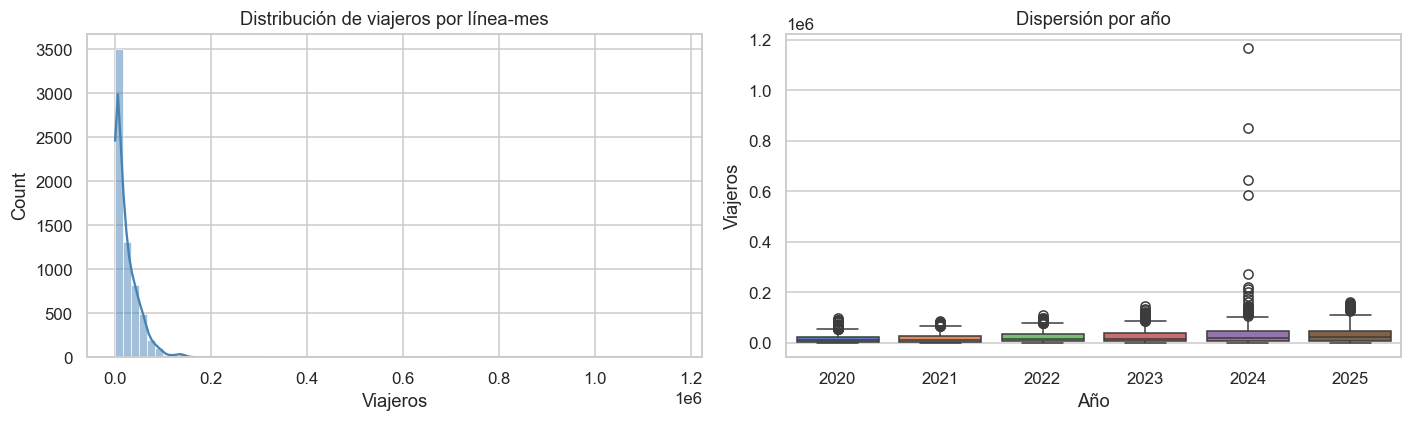

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_outlier_check['total'], bins=70, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Distribución de viajeros por línea-mes')
axes[0].set_xlabel('Viajeros')

sns.boxplot(data=df_outlier_check, x='ejercicio', y='total', ax=axes[1], palette='muted')
axes[1].set_title('Dispersión por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Viajeros')

plt.tight_layout()
plt.show()


In [14]:
# Los outliers son líneas de alta frecuencia (troncales) → totalmente válidos.
# NO los eliminamos. Solo creamos df_activo después de las transformaciones.
print(f"df.shape: {df.shape}  (incluye líneas con total=0)")


df.shape: (6852, 16)  (incluye líneas con total=0)


## 4. Transformaciones y Feature Engineering

### 4.1 Columna de Fecha y Nombre de Mes

In [15]:
df['fecha'] = pd.to_datetime(
    df['ejercicio'].astype(str) + '-' + df['mes'].astype(str).str.zfill(2) + '-01'
)

MESES_ES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df['mes_nombre'] = df['mes'].map(MESES_ES)

print(f"Rango temporal del dataset:")
print(f"  · Inicio : {df['fecha'].min().strftime('%B %Y')}")
print(f"  · Fin    : {df['fecha'].max().strftime('%B %Y')}")
print(f"  · Períodos únicos: {df['fecha'].nunique()}")


Rango temporal del dataset:
  · Inicio : January 2020
  · Fin    : December 2025
  · Períodos únicos: 72


### 4.2 Flag Pre / Post Subsidio

El **subsidio del 50%** en transporte público de Euskadi entró en vigor en **septiembre de 2022**.  
Usaremos esta fecha como punto de corte para el análisis de H4.


In [16]:
SUBSIDIO_INICIO = pd.Timestamp('2022-09-01')

df['periodo_subsidio'] = df['fecha'].apply(
    lambda x: 'Post-subsidio (>=Sep 2022)' if x >= SUBSIDIO_INICIO else 'Pre-subsidio (<Sep 2022)'
)

print("Meses por período:")
print(df.groupby('periodo_subsidio')['fecha'].nunique().rename('n_meses'))


Meses por período:
periodo_subsidio
Post-subsidio (>=Sep 2022)    40
Pre-subsidio (<Sep 2022)      32
Name: n_meses, dtype: int64


### 4.3 Flag Líneas con Conexión a Bilbao

In [17]:
df['conecta_bilbao'] = df['linea'].str.upper().str.contains('BILBAO', na=False)

resumen_bilbao = df.groupby('conecta_bilbao')['linea'].nunique()
print("Líneas únicas por flag:")
print(resumen_bilbao.rename({True: 'Conecta Bilbao', False: 'No conecta Bilbao'}))


Líneas únicas por flag:
conecta_bilbao
No conecta Bilbao    55
Conecta Bilbao       49
Name: linea, dtype: int64


### 4.4 Grupos de Viajeros por Perfil

Creamos columnas agregadas para facilitar la comparativa por segmento:

| Columna | Títulos incluidos | Perfil |
|---|---|---|
| `jovenes` | gazte_70 + goro | Menores de 26 años |
| `adultos` | creditrans + b50 + b70 + boro | Adultos 26-65 |
| `mayores` | gizatrans | Mayores de 65 |
| `turistas` | bbcard | Turistas |


In [18]:
df['jovenes']  = df['gazte_70'] + df['goro']
df['adultos']  = df['creditrans'] + df['b50'] + df['b70'] + df['boro']
df['mayores']  = df['gizatrans']
df['turistas'] = df['bbcard']

# DataFrame de trabajo: excluimos líneas sin actividad
df_activo = df[df['total'] > 0].copy()

print(f"df        → {df.shape[0]:,} filas (incluye líneas inactivas)")
print(f"df_activo → {df_activo.shape[0]:,} filas (total > 0)")
print()
print("Vista previa del DataFrame final:")
df_activo.head()


df        → 6,852 filas (incluye líneas inactivas)
df_activo → 6,544 filas (total > 0)

Vista previa del DataFrame final:


,ejercicio,mes,codigo,linea,creditrans,gizatrans,bbcard,gazte_70,goro,b50,b70,boro,bat,ocasional,familia_numerosa,total,fecha,mes_nombre,periodo_subsidio,conecta_bilbao,jovenes,adultos,mayores,turistas
0,2020,7,A2610,GALDAKAO - UPV/EHU,869,51,0,30,5,0,0,0,0,0,0,957,2020-07-01,Jul,Pre-subsidio (<Sep 2022),False,35,869,51,0
2,2020,7,A3613,BILBAO - UGAO MIRABALLES - OROZKO,"14,587","6,339",0,245,284,0,0,0,0,0,0,"21,793",2020-07-01,Jul,Pre-subsidio (<Sep 2022),True,529,"14,587","6,339",0
3,2020,7,A3622,BILBAO - BASAURI - Artunduaga - San Miguel -ZA...,"5,517","1,759",1,117,117,0,0,0,0,0,0,"7,713",2020-07-01,Jul,Pre-subsidio (<Sep 2022),True,234,"5,517","1,759",1
4,2020,7,A3631,BILBAO - GALDAKAO - LARRABETZU,"14,056","3,632",0,205,294,0,0,0,0,0,0,"18,633",2020-07-01,Jul,Pre-subsidio (<Sep 2022),True,499,"14,056","3,632",0
5,2020,7,A3632,BILBAO - ETXEBARRI - BASAURI - San Miguel (Beg...,"2,617",696,0,81,89,0,0,0,0,0,0,"3,644",2020-07-01,Jul,Pre-subsidio (<Sep 2022),True,170,"2,617",696,0


## 5. Análisis Univariante

### 5.1 Viajeros Totales por Año

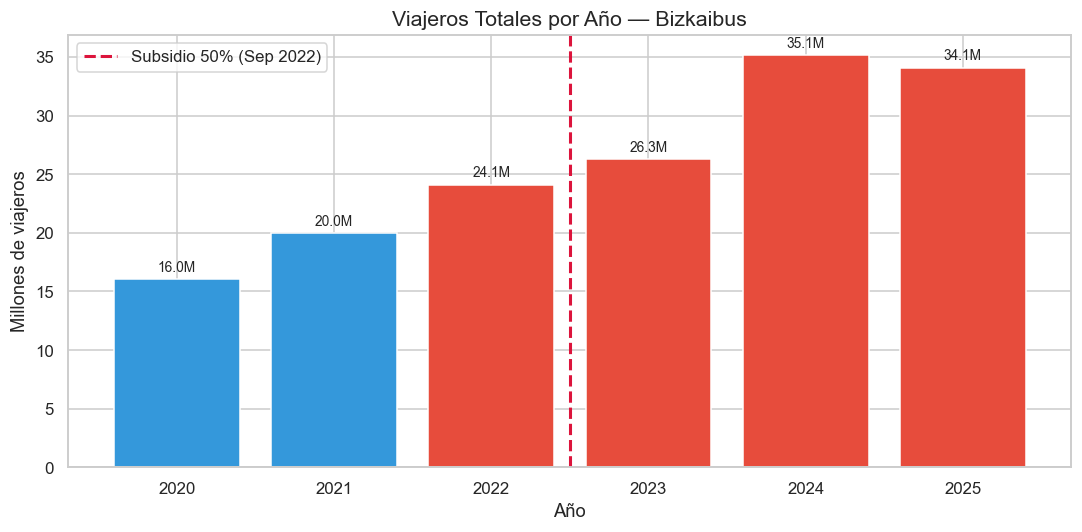

 ejercicio      total
      2020 16,039,334
      2021 19,959,240
      2022 24,114,302
      2023 26,303,100
      2024 35,136,186
      2025 34,092,299


In [19]:
viajeros_anio = df.groupby('ejercicio')['total'].sum().reset_index()
viajeros_anio['total_M'] = viajeros_anio['total'] / 1_000_000

fig, ax = plt.subplots(figsize=(10, 5))
colores_barra = ['#e74c3c' if y >= 2022 else '#3498db' for y in viajeros_anio['ejercicio']]
bars = ax.bar(viajeros_anio['ejercicio'].astype(str), viajeros_anio['total_M'], color=colores_barra)
ax.bar_label(bars, fmt='{:.1f}M', padding=3, fontsize=9)
ax.axvline(x=2.5, color='crimson', linestyle='--', linewidth=2,
           label='Subsidio 50% (Sep 2022)')
ax.set_title('Viajeros Totales por Año — Bizkaibus', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Millones de viajeros')
ax.legend()
plt.tight_layout()
plt.show()

print(viajeros_anio[['ejercicio', 'total']].to_string(index=False))


### 5.2 Top 15 Líneas por Total Histórico de Viajeros

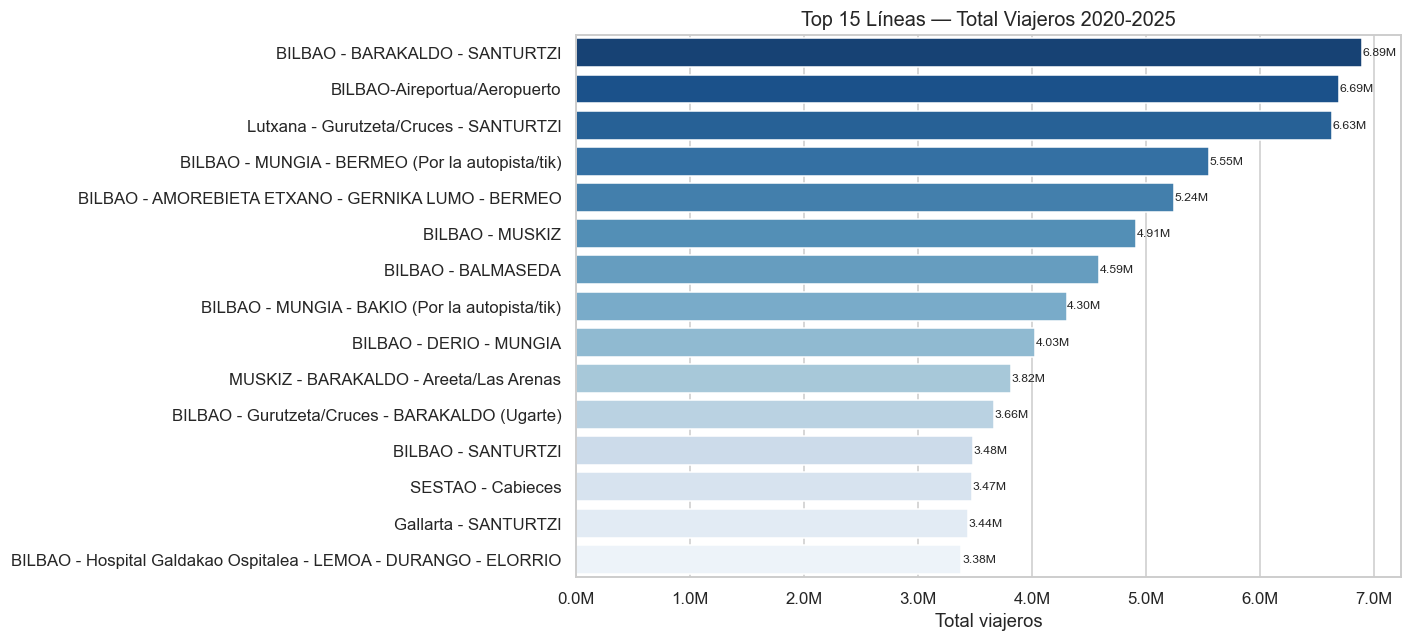

In [20]:
top_lineas = (df_activo.groupby('linea')['total']
              .sum().sort_values(ascending=False).head(15).reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=top_lineas, y='linea', x='total', palette='Blues_r', ax=ax)
ax.set_title('Top 15 Líneas — Total Viajeros 2020-2025', fontsize=13)
ax.set_xlabel('Total viajeros')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, (_, row) in enumerate(top_lineas.iterrows()):
    ax.text(row['total'] + 5000, i, f"{row['total']/1e6:.2f}M",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Distribución Total por Tipo de Título

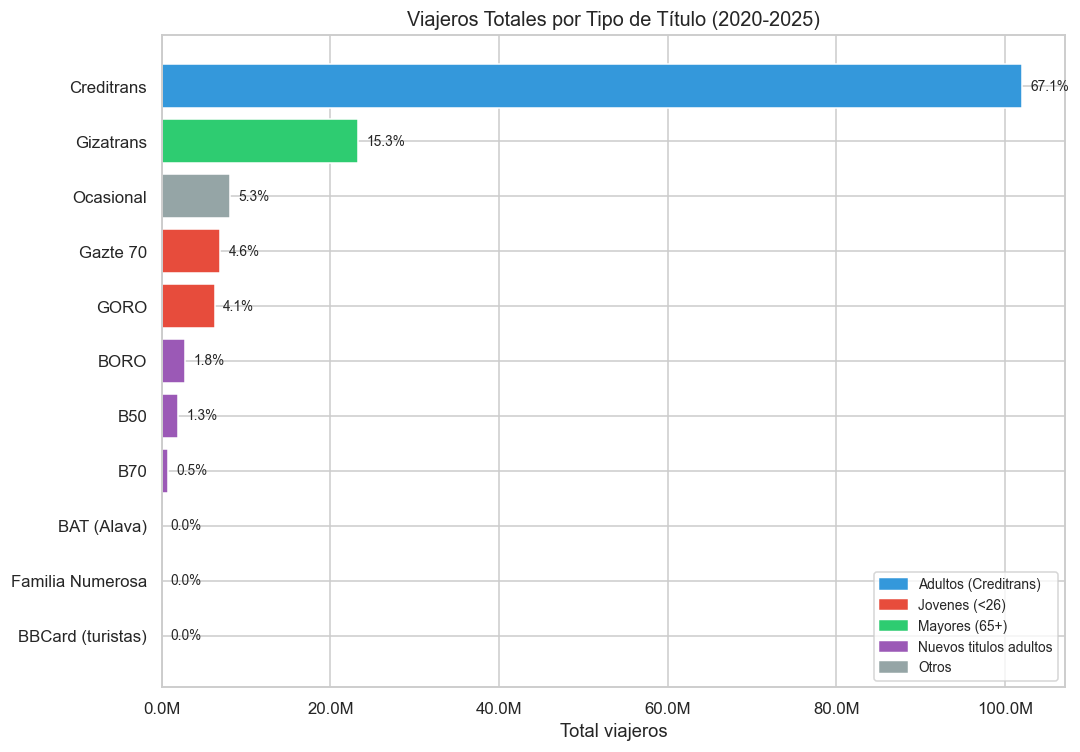

In [21]:
totales = {
    'Creditrans':        df['creditrans'].sum(),
    'Gazte 70':          df['gazte_70'].sum(),
    'GORO':              df['goro'].sum(),
    'Gizatrans':         df['gizatrans'].sum(),
    'B50':               df['b50'].sum(),
    'B70':               df['b70'].sum(),
    'BORO':              df['boro'].sum(),
    'BBCard (turistas)': df['bbcard'].sum(),
    'Ocasional':         df['ocasional'].sum(),
    'Familia Numerosa':  df['familia_numerosa'].sum(),
    'BAT (Alava)':       df['bat'].sum(),
}
s_titulos = pd.Series(totales).sort_values(ascending=True)
pct = (s_titulos / s_titulos.sum() * 100).round(1)

def color_titulo(k):
    if 'Gazte' in k or 'GORO' in k: return '#e74c3c'
    if 'Creditrans' in k: return '#3498db'
    if 'Gizatrans' in k: return '#2ecc71'
    if 'B50' in k or 'B70' in k or 'BORO' in k: return '#9b59b6'
    return '#95a5a6'

colores = [color_titulo(k) for k in s_titulos.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(s_titulos.index, s_titulos.values, color=colores)
for bar, p in zip(bars, pct):
    ax.text(bar.get_width() + s_titulos.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{p}%', va='center', fontsize=9)
ax.set_title('Viajeros Totales por Tipo de Título (2020-2025)', fontsize=13)
ax.set_xlabel('Total viajeros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#3498db', label='Adultos (Creditrans)'),
    Patch(color='#e74c3c', label='Jovenes (<26)'),
    Patch(color='#2ecc71', label='Mayores (65+)'),
    Patch(color='#9b59b6', label='Nuevos titulos adultos'),
    Patch(color='#95a5a6', label='Otros'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### 5.4 Distribución del Total por Línea-Mes

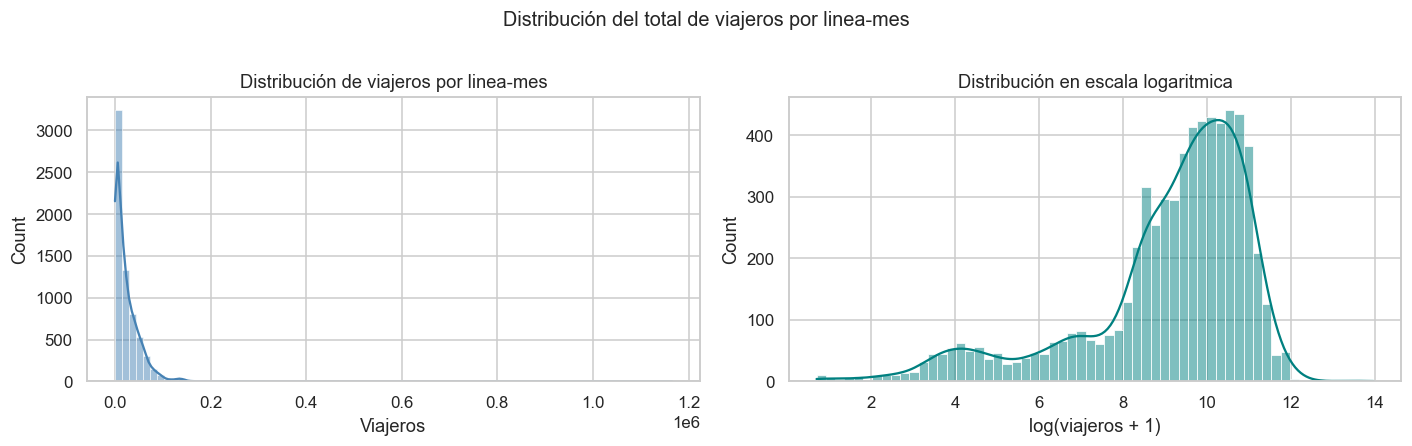

Media:     23,784
Mediana:   14,882
Std:       32,720
Max:     1,165,317


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_activo['total'], bins=80, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Distribución de viajeros por linea-mes')
axes[0].set_xlabel('Viajeros')
axes[0].yaxis.grid(True)

sns.histplot(np.log1p(df_activo['total']), bins=60, ax=axes[1], color='teal', kde=True)
axes[1].set_title('Distribución en escala logaritmica')
axes[1].set_xlabel('log(viajeros + 1)')
axes[1].yaxis.grid(True)

fig.suptitle('Distribución del total de viajeros por linea-mes', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Media:   {df_activo['total'].mean():>8,.0f}")
print(f"Mediana: {df_activo['total'].median():>8,.0f}")
print(f"Std:     {df_activo['total'].std():>8,.0f}")
print(f"Max:     {df_activo['total'].max():>8,.0f}")


## 6. Análisis Bivariante

### 6.1 Heatmap de Viajeros por Año y Mes

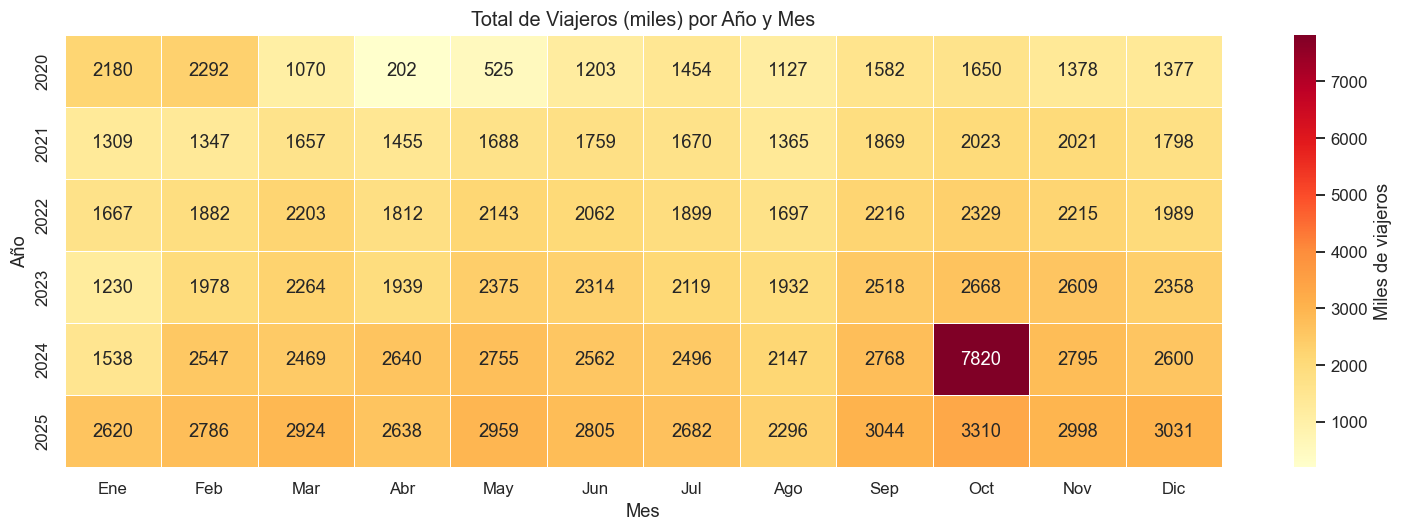

In [23]:
pivot = (df.groupby(['ejercicio', 'mes'])['total']
          .sum()
          .unstack(fill_value=0))
pivot.columns = [MESES_ES[m] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot / 1_000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Miles de viajeros'})
ax.set_title('Total de Viajeros (miles) por Año y Mes', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()


### 6.2 Evolución Temporal del Total de Viajeros

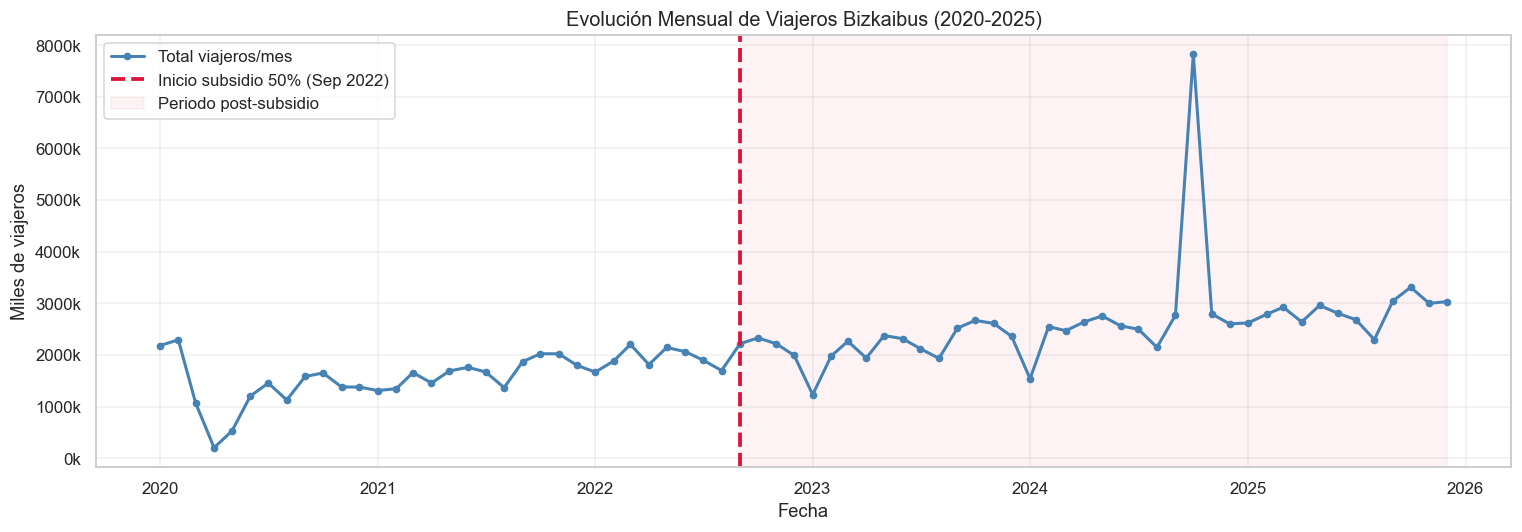

In [24]:
evolucion = df.groupby('fecha')['total'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(evolucion['fecha'], evolucion['total'] / 1_000, marker='o', markersize=4,
        color='steelblue', linewidth=2, label='Total viajeros/mes')
ax.axvline(SUBSIDIO_INICIO, color='crimson', linestyle='--', linewidth=2.5,
           label='Inicio subsidio 50% (Sep 2022)')
ax.axvspan(SUBSIDIO_INICIO, evolucion['fecha'].max(), alpha=0.05, color='crimson',
           label='Periodo post-subsidio')
ax.set_title('Evolución Mensual de Viajeros Bizkaibus (2020-2025)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Miles de viajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.3 Evolución por Tipo de Título (con punto de corte del subsidio)

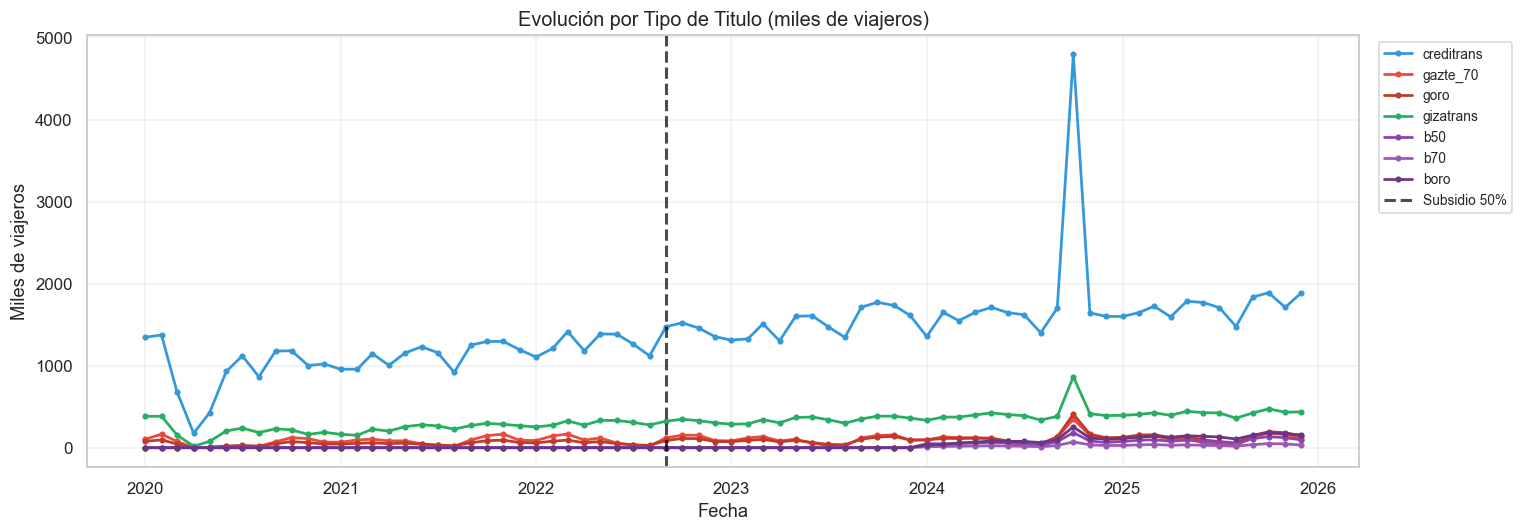

In [25]:
titulos_tiempo = (df.groupby('fecha')[
    ['creditrans','gazte_70','goro','gizatrans','b50','b70','boro']
].sum().reset_index())

PALETA = {
    'creditrans': '#3498db',
    'gazte_70':   '#e74c3c',
    'goro':       '#c0392b',
    'gizatrans':  '#27ae60',
    'b50':        '#8e44ad',
    'b70':        '#9b59b6',
    'boro':       '#6c3483',
}

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in PALETA.items():
    ax.plot(titulos_tiempo['fecha'], titulos_tiempo[col] / 1_000,
            label=col, color=color, linewidth=1.8, marker='o', markersize=3)
ax.axvline(SUBSIDIO_INICIO, color='black', linestyle='--', linewidth=2, alpha=0.7,
           label='Subsidio 50%')
ax.set_title('Evolución por Tipo de Titulo (miles de viajeros)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Miles de viajeros')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Correlación entre Tipos de Título

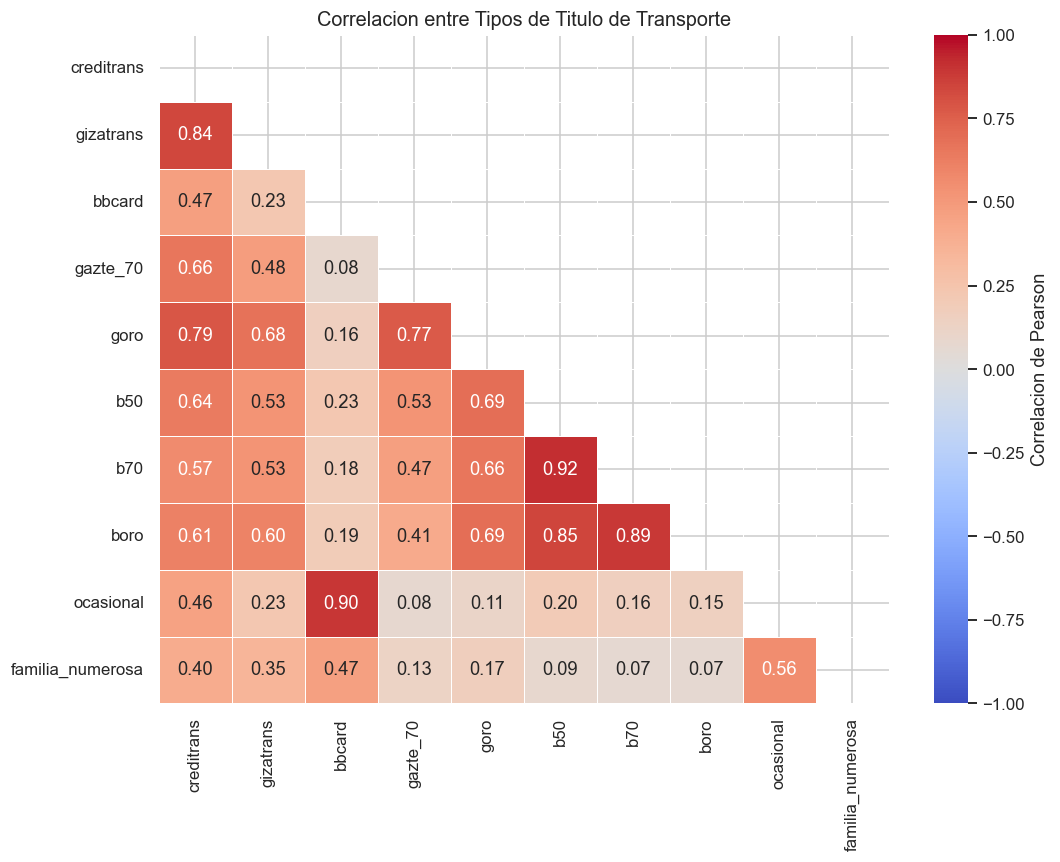

In [26]:
CORR_COLS = ['creditrans','gizatrans','bbcard','gazte_70','goro',
             'b50','b70','boro','ocasional','familia_numerosa']

corr = df_activo[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlacion de Pearson'})
ax.set_title('Correlacion entre Tipos de Titulo de Transporte', fontsize=13)
plt.tight_layout()
plt.show()


### 6.5 Líneas con Bilbao vs Sin Bilbao — Evolución Temporal

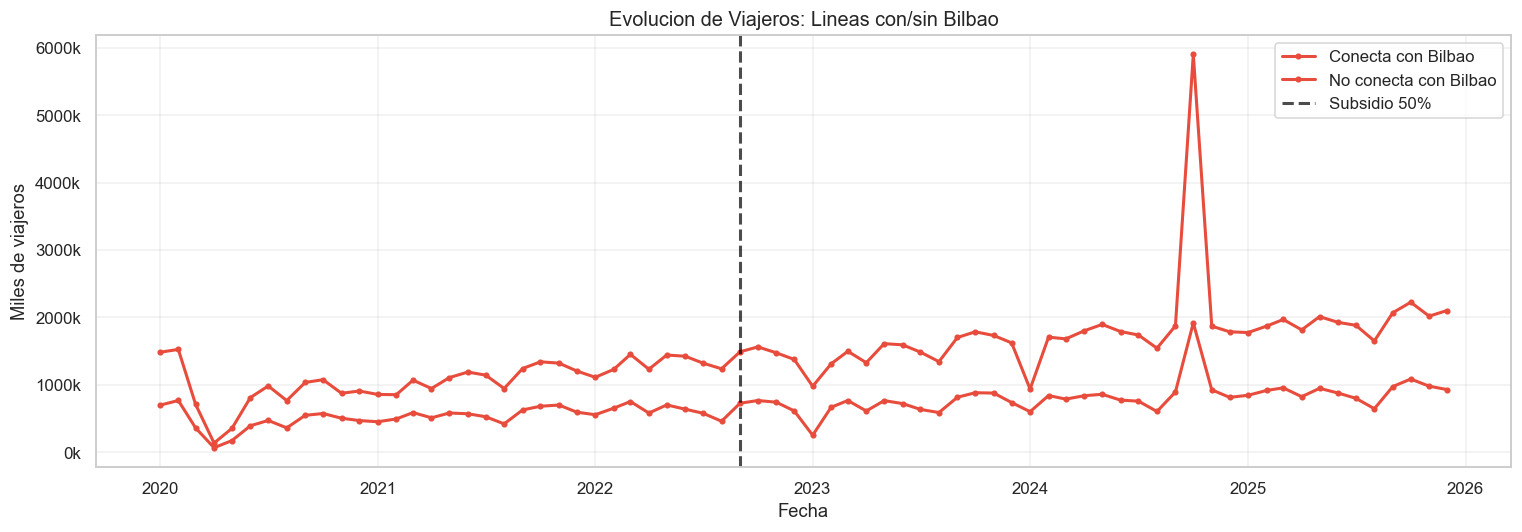

In [27]:
evol_bilbao = (df_activo.groupby(['fecha','conecta_bilbao'])['total']
               .sum().reset_index())
evol_bilbao['tipo'] = evol_bilbao['conecta_bilbao'].map(
    {True: 'Conecta con Bilbao', False: 'No conecta con Bilbao'})

fig, ax = plt.subplots(figsize=(14, 5))
for tipo, grupo in evol_bilbao.groupby('tipo'):
    color = '#e74c3c' if 'Bilbao' in tipo else '#3498db'
    ax.plot(grupo['fecha'], grupo['total'] / 1_000,
            label=tipo, color=color, linewidth=2, marker='o', markersize=3)
ax.axvline(SUBSIDIO_INICIO, color='black', linestyle='--', linewidth=2,
           label='Subsidio 50%', alpha=0.7)
ax.set_title('Evolucion de Viajeros: Lineas con/sin Bilbao', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Miles de viajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Análisis Multivariante

### 7.1 Composición de Viajeros por Año (Stacked Bar por Grupo)

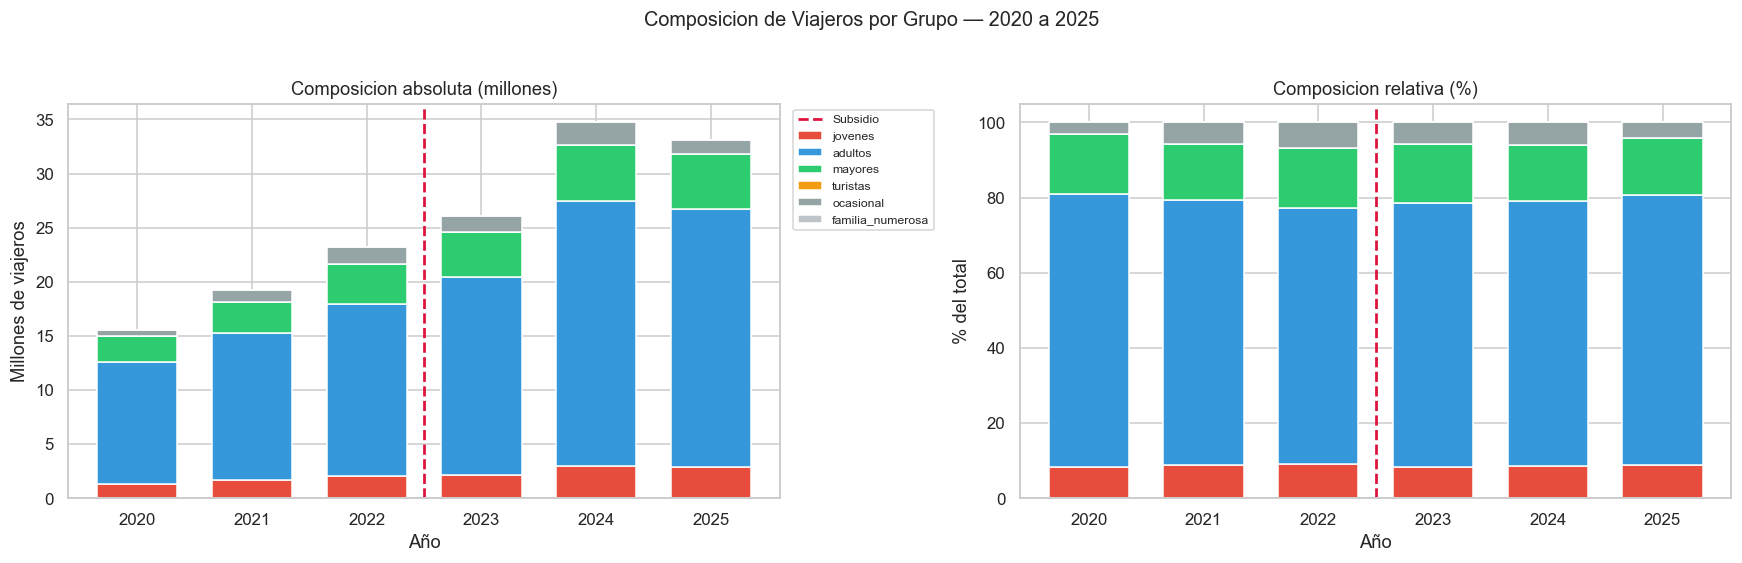

In [28]:
composicion = df.groupby('ejercicio')[
    ['jovenes','adultos','mayores','turistas','ocasional','familia_numerosa']
].sum()

# En porcentaje
comp_pct = composicion.div(composicion.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolutos
(composicion / 1e6).plot(kind='bar', stacked=True, ax=axes[0],
    color=['#e74c3c','#3498db','#2ecc71','#f39c12','#95a5a6','#bdc3c7'],
    width=0.7, edgecolor='white')
axes[0].set_title('Composicion absoluta (millones)', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Millones de viajeros')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].axvline(x=2.5, color='crimson', linestyle='--', linewidth=1.8, label='Subsidio')
axes[0].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

# Porcentaje
comp_pct.plot(kind='bar', stacked=True, ax=axes[1],
    color=['#e74c3c','#3498db','#2ecc71','#f39c12','#95a5a6','#bdc3c7'],
    width=0.7, edgecolor='white')
axes[1].set_title('Composicion relativa (%)', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% del total')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].axvline(x=2.5, color='crimson', linestyle='--', linewidth=1.8)
axes[1].get_legend().remove()

plt.suptitle('Composicion de Viajeros por Grupo — 2020 a 2025', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 7.2 Crecimiento 2020→2025 por Línea (Scatter Bilbao vs Resto)

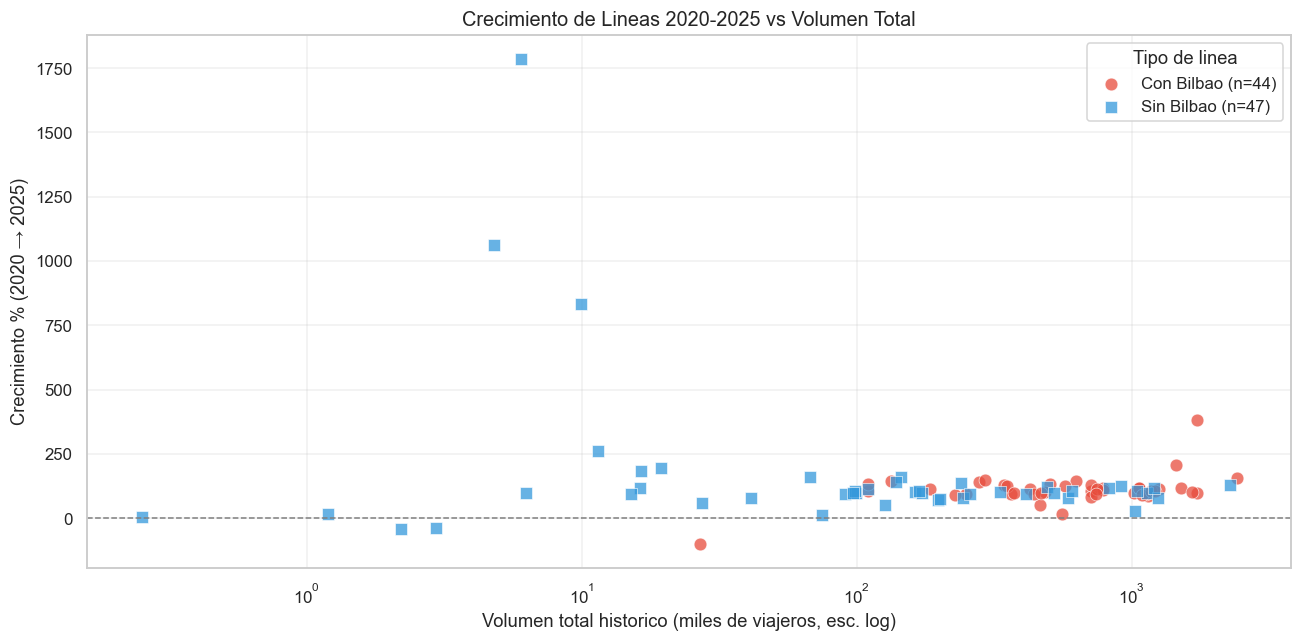

Media crecimiento - Con Bilbao: 112.7%
Media crecimiento - Sin Bilbao: 168.6%


In [29]:
# Agregamos por línea y año
lineas_2020 = df[df['ejercicio']==2020].groupby('linea')['total'].sum().rename('t2020')
lineas_2025 = df[df['ejercicio']==2025].groupby('linea')['total'].sum().rename('t2025')
crecimiento = pd.concat([lineas_2020, lineas_2025], axis=1).dropna()
crecimiento = crecimiento[crecimiento['t2020'] > 0]
crecimiento['crec_pct'] = (crecimiento['t2025'] - crecimiento['t2020']) / crecimiento['t2020'] * 100
crecimiento['tipo'] = crecimiento.index.map(
    lambda x: 'Con Bilbao' if 'BILBAO' in str(x).upper() else 'Sin Bilbao')
crecimiento['vol_total'] = crecimiento['t2020'] + crecimiento['t2025']

fig, ax = plt.subplots(figsize=(12, 6))
for tipo, color, marker in [('Con Bilbao','#e74c3c','o'), ('Sin Bilbao','#3498db','s')]:
    sub = crecimiento[crecimiento['tipo'] == tipo]
    ax.scatter(sub['vol_total'] / 1_000, sub['crec_pct'],
               label=f"{tipo} (n={len(sub)})", color=color, marker=marker,
               alpha=0.75, s=70, edgecolors='white', linewidth=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Crecimiento de Lineas 2020-2025 vs Volumen Total', fontsize=13)
ax.set_xlabel('Volumen total historico (miles de viajeros, esc. log)')
ax.set_ylabel('Crecimiento % (2020 → 2025)')
ax.set_xscale('log')
ax.legend(title='Tipo de linea')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Media crecimiento - Con Bilbao: "
      f"{crecimiento[crecimiento['tipo']=='Con Bilbao']['crec_pct'].mean():.1f}%")
print(f"Media crecimiento - Sin Bilbao: "
      f"{crecimiento[crecimiento['tipo']=='Sin Bilbao']['crec_pct'].mean():.1f}%")


### 7.3 Adopción de Nuevos Títulos Adultos (B50 / B70 / BORO) a lo largo del tiempo

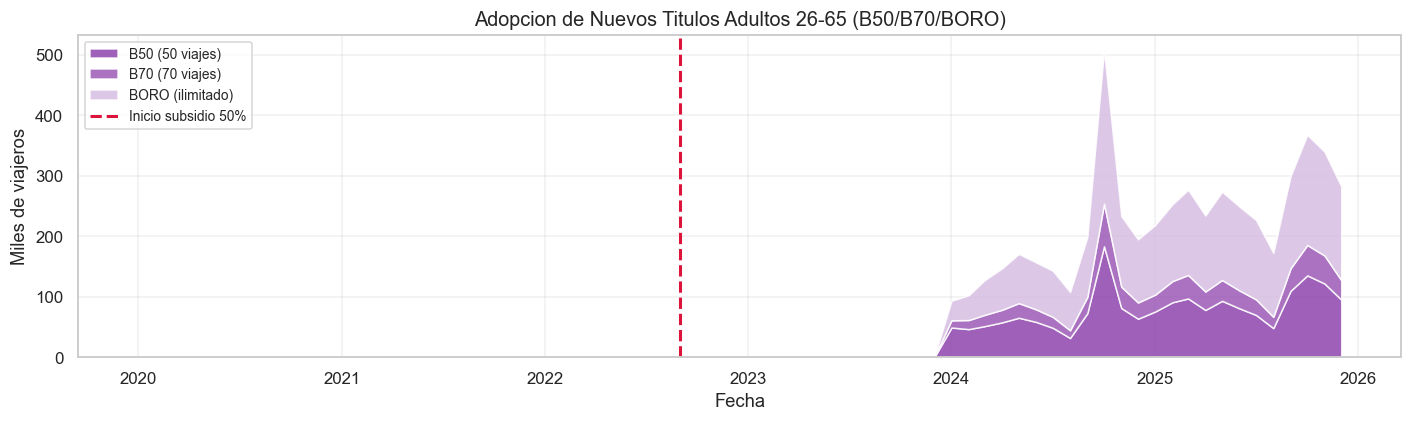

In [30]:
nuevos = df.groupby('fecha')[['b50','b70','boro']].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.stackplot(nuevos['fecha'],
             nuevos['b50'] / 1_000,
             nuevos['b70'] / 1_000,
             nuevos['boro'] / 1_000,
             labels=['B50 (50 viajes)', 'B70 (70 viajes)', 'BORO (ilimitado)'],
             colors=['#8e44ad','#9b59b6','#d7bde2'], alpha=0.85)
ax.axvline(SUBSIDIO_INICIO, color='crimson', linestyle='--', linewidth=2,
           label='Inicio subsidio 50%')
ax.set_title('Adopcion de Nuevos Titulos Adultos 26-65 (B50/B70/BORO)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Miles de viajeros')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 7.4 Facet Grid — Evolución Jóvenes vs Adultos nuevos vs Mayores por Año

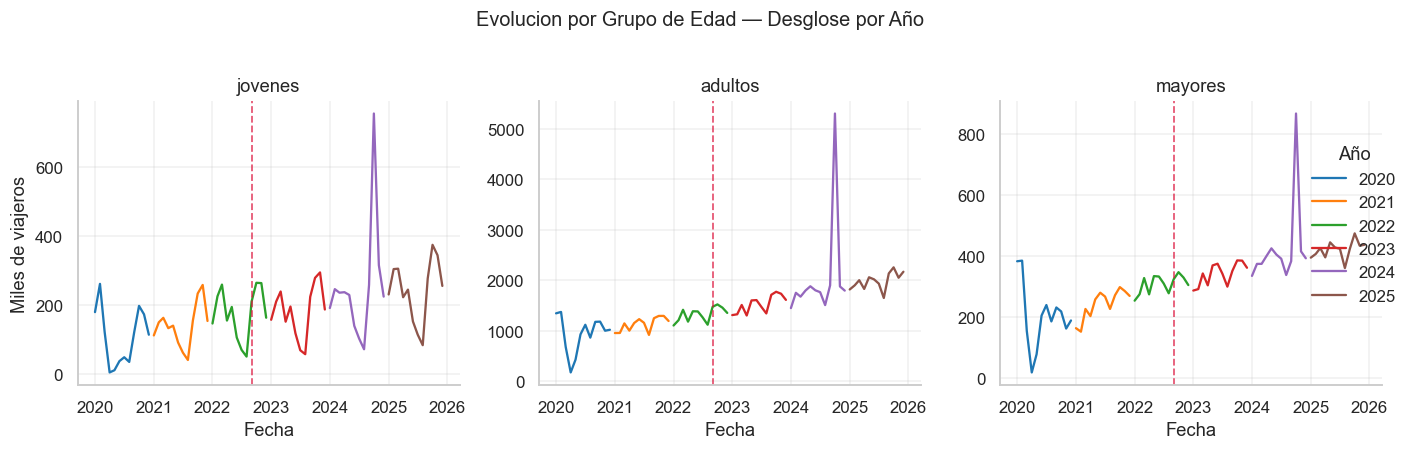

In [31]:
grupos_tiempo = (df.groupby(['fecha','ejercicio'])[['jovenes','adultos','mayores']]
                  .sum().reset_index())
grupos_long = grupos_tiempo.melt(
    id_vars=['fecha','ejercicio'], var_name='grupo', value_name='viajeros')
grupos_long['viajeros_k'] = grupos_long['viajeros'] / 1_000

g = sns.FacetGrid(grupos_long, col='grupo', col_wrap=3,
                  height=4, sharey=False, sharex=True)
g.map_dataframe(sns.lineplot, x='fecha', y='viajeros_k',
                hue='ejercicio', palette='tab10', linewidth=1.5)
g.set_axis_labels('Fecha', 'Miles de viajeros')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axvline(SUBSIDIO_INICIO, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.grid(True, alpha=0.3)
g.add_legend(title='Año')
g.figure.suptitle('Evolucion por Grupo de Edad — Desglose por Año', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 8. Contraste de Hipótesis

### H1 — *"Los títulos bonificados para jóvenes representan una proporción significativa del total de viajeros"*

Consideramos "significativa" si los viajeros jóvenes (`gazte_70 + goro`) superan el **15% del total**.


Total viajeros jovenes (<26):   13,171,783
Total viajeros (todas):        155,644,461
Proporcion jovenes:           8.46%


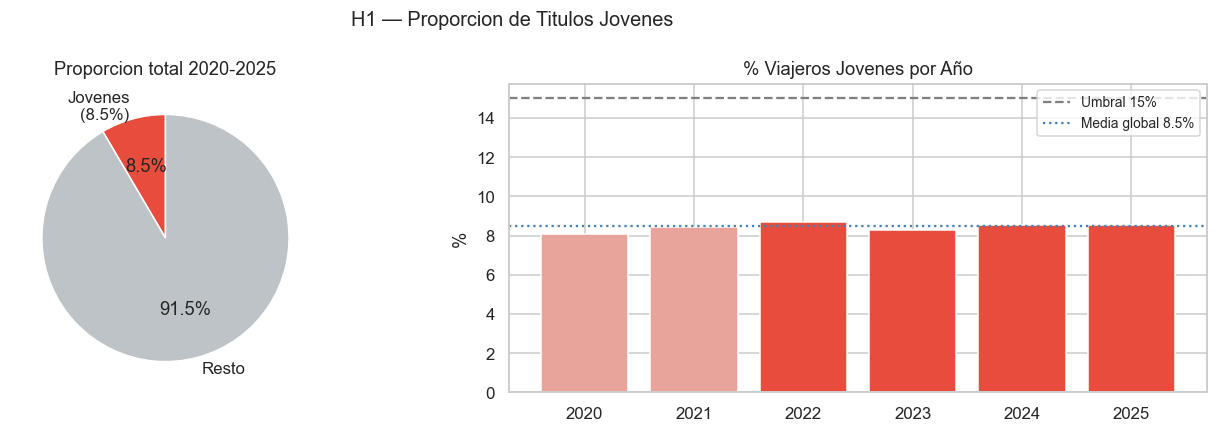


H1 → NO CONFIRMADA
  Proporcion jovenes: 8.5% (umbral: 15%)


In [32]:
jovenes_total = df['jovenes'].sum()
gran_total    = df['total'].sum()
pct_jovenes   = jovenes_total / gran_total * 100

print(f"Total viajeros jovenes (<26): {jovenes_total:>12,.0f}")
print(f"Total viajeros (todas):       {gran_total:>12,.0f}")
print(f"Proporcion jovenes:           {pct_jovenes:.2f}%")

# Evolución anual
prop_anio = (df.groupby('ejercicio')
               .apply(lambda x: x['jovenes'].sum() / x['total'].sum() * 100)
               .reset_index(name='pct_jovenes'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie total histórico
axes[0].pie([pct_jovenes, 100 - pct_jovenes],
            labels=[f'Jovenes\n({pct_jovenes:.1f}%)', 'Resto'],
            colors=['#e74c3c', '#bdc3c7'], startangle=90, autopct='%1.1f%%',
            wedgeprops={'edgecolor':'white'})
axes[0].set_title('Proporcion total 2020-2025')

# Barra por año
col_barras = ['#e74c3c' if y >= 2022 else '#e8a49a' for y in prop_anio['ejercicio']]
axes[1].bar(prop_anio['ejercicio'].astype(str), prop_anio['pct_jovenes'], color=col_barras)
axes[1].axhline(15, color='gray', linestyle='--', linewidth=1.5, label='Umbral 15%')
axes[1].axhline(pct_jovenes, color='steelblue', linestyle=':', linewidth=1.5,
                label=f'Media global {pct_jovenes:.1f}%')
axes[1].set_title('% Viajeros Jovenes por Año')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=9)

plt.suptitle('H1 — Proporcion de Titulos Jovenes', fontsize=13)
plt.tight_layout()
plt.show()

UMBRAL_H1 = 15
veredicto_H1 = "CONFIRMADA" if pct_jovenes >= UMBRAL_H1 else "NO CONFIRMADA"
print(f"\n{'='*50}")
print(f"H1 → {veredicto_H1}")
print(f"  Proporcion jovenes: {pct_jovenes:.1f}% (umbral: {UMBRAL_H1}%)")
print(f"{'='*50}")


### H2 — *"Hay meses con más afluencia que otros"*

Medimos la variabilidad entre meses con el **coeficiente de variación (CV)**.  
Si CV > 10% consideramos que la estacionalidad mensual es notable.


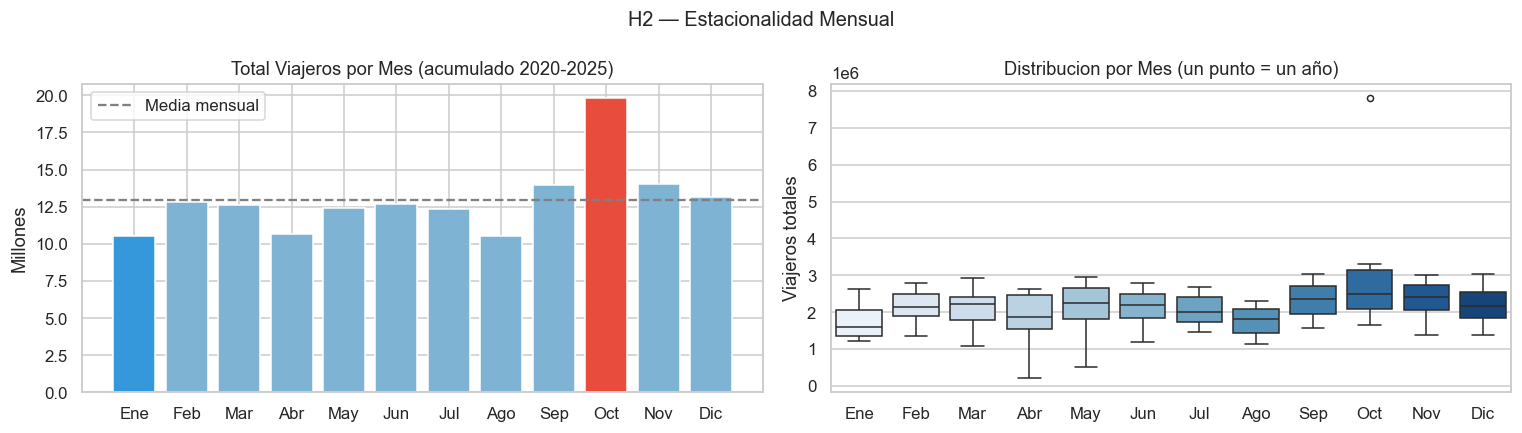

Coeficiente de Variacion entre meses: 19.0%
Mes mas concurrido:  Oct
Mes menos concurrido: Ene

H2 → CONFIRMADA  (CV = 19.0%)


In [33]:
viajeros_mes = df.groupby('mes')['total'].sum().reset_index()
viajeros_mes['mes_nombre'] = viajeros_mes['mes'].map(MESES_ES)
orden_meses = [MESES_ES[i] for i in range(1, 13)]
vm_ord = viajeros_mes.set_index('mes_nombre').reindex(orden_meses)

media_mes = viajeros_mes['total'].mean()
cv = viajeros_mes['total'].std() / media_mes * 100

mes_max = viajeros_mes.loc[viajeros_mes['total'].idxmax(), 'mes_nombre']
mes_min = viajeros_mes.loc[viajeros_mes['total'].idxmin(), 'mes_nombre']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Barplot mensual acumulado
colores_mes = ['#e74c3c' if m == mes_max else '#3498db' if m == mes_min else '#7fb3d3'
               for m in orden_meses]
axes[0].bar(orden_meses, vm_ord['total'] / 1e6, color=colores_mes)
axes[0].axhline(media_mes / 1e6, color='gray', linestyle='--', linewidth=1.5,
                label=f'Media mensual')
axes[0].set_title('Total Viajeros por Mes (acumulado 2020-2025)')
axes[0].set_ylabel('Millones')
axes[0].legend()

# Boxplot por año
mes_anio = df.groupby(['mes','ejercicio'])['total'].sum().reset_index()
mes_anio['mes_nombre'] = pd.Categorical(
    mes_anio['mes'].map(MESES_ES), categories=orden_meses, ordered=True)
sns.boxplot(data=mes_anio.sort_values('mes_nombre'), x='mes_nombre', y='total',
            ax=axes[1], palette='Blues', flierprops={'markersize': 4})
axes[1].set_title('Distribucion por Mes (un punto = un año)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Viajeros totales')

plt.suptitle('H2 — Estacionalidad Mensual', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Coeficiente de Variacion entre meses: {cv:.1f}%")
print(f"Mes mas concurrido:  {mes_max}")
print(f"Mes menos concurrido: {mes_min}")

veredicto_H2 = "CONFIRMADA" if cv > 10 else "DEBIL"
print(f"\n{'='*50}")
print(f"H2 → {veredicto_H2}  (CV = {cv:.1f}%)")
print(f"{'='*50}")


### H3 — *"Las líneas que más crecen son las que conectan con Bilbao"*

Comparamos el crecimiento porcentual 2020→2025 entre líneas con y sin Bilbao en su recorrido.


Crecimiento 2020→2025 por tipo de linea:
            mean  median  std  count
tipo                                
Con Bilbao   113     109   60     44
Sin Bilbao   169     100  303     47


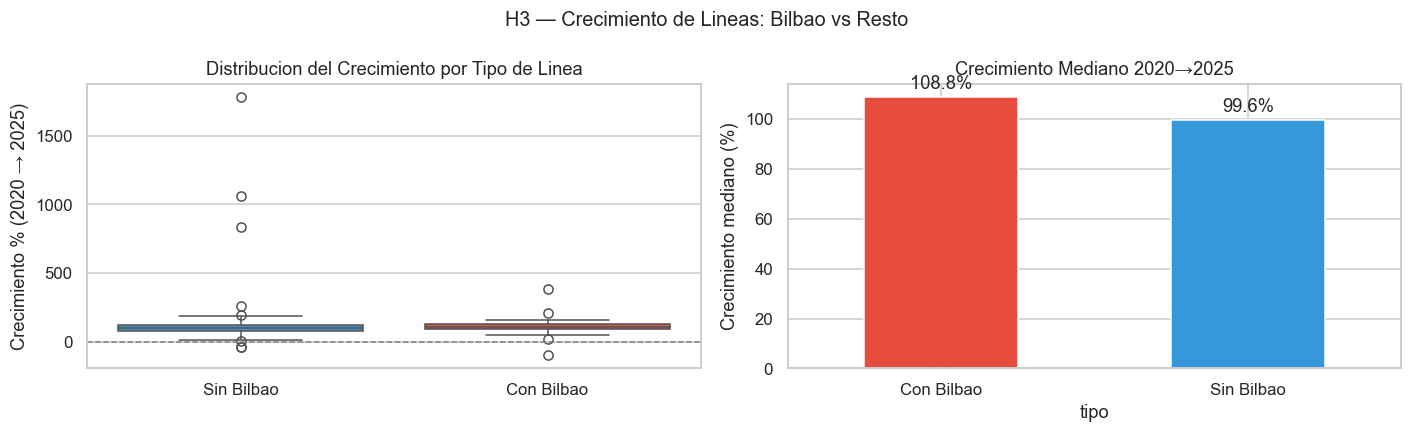


H3 → NO CONFIRMADA
  Crecimiento medio - Con Bilbao: 112.7%
  Crecimiento medio - Sin Bilbao: 168.6%


In [34]:
stats = (crecimiento.groupby('tipo')['crec_pct']
         .agg(['mean','median','std','count'])
         .round(1))
print("Crecimiento 2020→2025 por tipo de linea:")
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=crecimiento, x='tipo', y='crec_pct',
            palette={'Con Bilbao':'#e74c3c', 'Sin Bilbao':'#3498db'}, ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Distribucion del Crecimiento por Tipo de Linea')
axes[0].set_xlabel('')
axes[0].set_ylabel('Crecimiento % (2020 → 2025)')

medias = crecimiento.groupby('tipo')['crec_pct'].median()
bars = medias.plot(kind='bar', ax=axes[1],
                   color=['#e74c3c','#3498db'], width=0.5, edgecolor='white')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Crecimiento Mediano 2020→2025')
axes[1].set_ylabel('Crecimiento mediano (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].bar_label(axes[1].containers[0], fmt='{:.1f}%', padding=3)

plt.suptitle('H3 — Crecimiento de Lineas: Bilbao vs Resto', fontsize=13)
plt.tight_layout()
plt.show()

m_bilbao = crecimiento[crecimiento['tipo']=='Con Bilbao']['crec_pct'].mean()
m_resto  = crecimiento[crecimiento['tipo']=='Sin Bilbao']['crec_pct'].mean()
veredicto_H3 = "CONFIRMADA" if m_bilbao > m_resto else "NO CONFIRMADA"
print(f"\n{'='*50}")
print(f"H3 → {veredicto_H3}")
print(f"  Crecimiento medio - Con Bilbao: {m_bilbao:.1f}%")
print(f"  Crecimiento medio - Sin Bilbao: {m_resto:.1f}%")
print(f"{'='*50}")


### H4 — *"Las ayudas al transporte han impulsado el uso del autobús"*

Comparamos la **media mensual de viajeros** antes y después del subsidio del 50%.

> ⚠️ **Nota metodológica:** 2020 estuvo afectado por el COVID-19, lo que deprime el baseline.  
> Para un análisis más robusto comparamos también el período 2021-ago 2022 (sin COVID) contra sep 2022-2025.


Estadisticos por periodo (incluye 2020 COVID):
                            media_mensual   total_sum  n_meses
periodo_subsidio                                              
Post-subsidio (>=Sep 2022)      2,607,018 104,280,736       40
Pre-subsidio (<Sep 2022)        1,605,116  51,363,725       32

Estadisticos por periodo (SIN 2020 COVID):
                     media_mensual
periodo_subsidio2                 
Post (>=Sep 2022)        2,607,018
Pre (2021-Ago 2022)      1,766,220


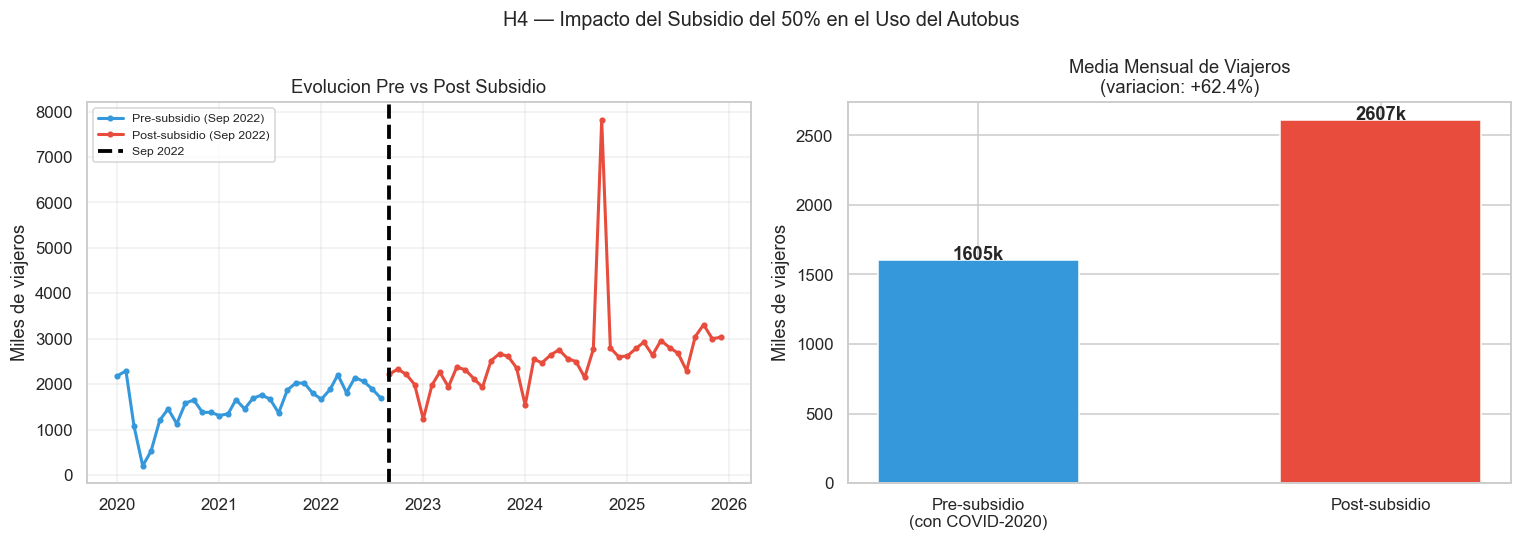


H4 → CONFIRMADA
  Media pre-subsidio:  1,605,116 viajeros/mes
  Media post-subsidio: 2,607,018 viajeros/mes
  Variacion:           +62.4%


In [35]:
# Media mensual por periodo
media_periodo = (df.groupby(['fecha','periodo_subsidio'])['total']
                 .sum().reset_index()
                 .groupby('periodo_subsidio')['total']
                 .agg(media_mensual='mean', total_sum='sum', n_meses='count')
                 .round(0))
print("Estadisticos por periodo (incluye 2020 COVID):")
print(media_periodo)

# Sin 2020 (periodo de pandemia)
df_sin2020 = df[df['ejercicio'] > 2020].copy()
df_sin2020['periodo_subsidio2'] = df_sin2020['fecha'].apply(
    lambda x: 'Post (>=Sep 2022)' if x >= SUBSIDIO_INICIO else 'Pre (2021-Ago 2022)')
media_sin2020 = (df_sin2020.groupby(['fecha','periodo_subsidio2'])['total']
                 .sum().reset_index()
                 .groupby('periodo_subsidio2')['total']
                 .agg(media_mensual='mean').round(0))
print("\nEstadisticos por periodo (SIN 2020 COVID):")
print(media_sin2020)

media_pre  = media_periodo.loc['Pre-subsidio (<Sep 2022)',  'media_mensual']
media_post = media_periodo.loc['Post-subsidio (>=Sep 2022)', 'media_mensual']
incremento = (media_post - media_pre) / media_pre * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución con area sombreada
evol2 = df.groupby(['fecha','periodo_subsidio'])['total'].sum().reset_index()
for periodo, color in [('Pre-subsidio (<Sep 2022)','#3498db'),
                       ('Post-subsidio (>=Sep 2022)','#e74c3c')]:
    sub = evol2[evol2['periodo_subsidio']==periodo]
    axes[0].plot(sub['fecha'], sub['total']/1_000, color=color,
                 linewidth=2, marker='o', markersize=3,
                 label=periodo.replace('(<','(').replace('(>=','('))
axes[0].axvline(SUBSIDIO_INICIO, color='black', linestyle='--', linewidth=2.5,
                label='Sep 2022')
axes[0].set_title('Evolucion Pre vs Post Subsidio')
axes[0].set_ylabel('Miles de viajeros')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Comparativa de medias
etiquetas = ['Pre-subsidio\n(con COVID-2020)', 'Post-subsidio']
valores = [media_pre / 1_000, media_post / 1_000]
colores_barra = ['#3498db', '#e74c3c']
axes[1].bar(etiquetas, valores, color=colores_barra, width=0.5, edgecolor='white')
for i, v in enumerate(valores):
    axes[1].text(i, v + 2, f'{v:.0f}k', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title(f'Media Mensual de Viajeros\n(variacion: +{incremento:.1f}%)')
axes[1].set_ylabel('Miles de viajeros')

plt.suptitle('H4 — Impacto del Subsidio del 50% en el Uso del Autobus', fontsize=13)
plt.tight_layout()
plt.show()

veredicto_H4 = "CONFIRMADA" if incremento > 5 else "DEBIL / NO CONFIRMADA"
print(f"\n{'='*50}")
print(f"H4 → {veredicto_H4}")
print(f"  Media pre-subsidio:  {media_pre:,.0f} viajeros/mes")
print(f"  Media post-subsidio: {media_post:,.0f} viajeros/mes")
print(f"  Variacion:           +{incremento:.1f}%")
print(f"{'='*50}")


## 9. Resumen de Hipótesis y Conclusiones

### Tabla resumen

| # | Hipótesis | Métrica clave | Veredicto |
|---|-----------|---------------|-----------|
| H1 | Títulos jóvenes = proporción significativa | % jóvenes sobre total | Ver celda H1 |
| H2 | Hay meses con más afluencia | Coeficiente de Variación mensual | Ver celda H2 |
| H3 | Líneas con Bilbao crecen más | Crecimiento medio 2020→2025 por tipo | Ver celda H3 |
| H4 | Subsidio impulsa el uso del autobús | Δ media mensual pre/post Sep 2022 | Ver celda H4 |

---

### Limitaciones del Análisis

- **Resolución temporal:** 2020-2022 tienen datos semestrales (2 archivos/año); 2023+ son trimestrales (4 archivos/año). No hay granularidad mensual individual en los primeros años.
- **Efecto COVID-19:** Los datos de 2020 están fuertemente deprimidos por la pandemia. Para H4 es importante usar también la comparativa sin 2020.
- **Nuevos títulos:** B50, B70, BORO y BAT solo existen desde 2024/2025, limitando su análisis longitudinal.
- **Identificación de líneas Bilbao:** Se usa la presencia de "BILBAO" en el nombre como proxy. Cruzar con los datos de expediciones (GTFS) daría un resultado más preciso.

---

### Próximos Pasos Sugeridos

1. **Cruzar con datos de expediciones** (Open Data Bizkaia — Expediciones y Refuerzos) para calcular la **tasa de ocupación** real por línea y detectar sobredemanda.
2. **Análisis de estacionalidad** con descomposición STL o Prophet para separar tendencia, estacionalidad y efecto subsidio.
3. **Comparativa modal:** cruzar con datos de metro y Euskotren para ver si el subsidio impulsó el transporte público en general o hubo trasvases entre modos.
4. **Análisis de nuevos segmentos:** estudiar la adopción de B50/B70/BORO como indicador de captación de viajeros adultos que antes usaban el coche privado.
